# LLM Text Annotations and Model Fine-Tuning

A news site with a comment section has more comments than anyone can read. Suppose we want to know whether the comments under political stories are nastier than the ones under sports. Before we can answer that, every comment needs a label, and there are 1.8 million of them.

So we hand the job to a model. This notebook takes one labelling task, measures how well a small open model does it cold, fine-tunes the model on 1,000 labelled comments, and checks whether any of the improvement survives a move to Wikipedia.

**Content warning.** These are real comments, and some of them are abusive. The examples below are the milder ones. A flag in the next cell controls whether stronger material is shown, and it is off. You can change `False` to `True` at the fifth line of cell 2 to enable it. 

**No GPU, no internet, no API key.** Every model answer was produced once locally and saved to a file. This notebook reads those files back, so it runs in about a minute and gives the same numbers every time.

In [1]:
import json
import re
import sys
from pathlib import Path

sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score, roc_auc_score
from sklearn.model_selection import cross_val_predict, cross_val_score
from IPython.display import Image

from model_call_scripts.cached_run import (
    RUBRIC, MODEL_ID, ADAPTER, SEED, CACHE_DIR, TOXIC_BAR,
    N_EVAL_PER_CLASS, N_PROBE_PER_CLASS, N_TRAIN,
    annotate, cached_records, read_set, MissingAnswers,
)

In [2]:
DATA = Path("data")
ARTIFACTS = DATA / "artifacts"
MEDIA = Path("media")
TRAIN_STEPS = 200

SHOW_STRONG = False     # print the comments raters found strongly toxic, switch to true if you want that

pd.set_option("display.max_colwidth", 90)

evaluation = read_set("civil_eval.csv")
probe = read_set("civil_probe.csv")
transfer = read_set("detox_eval.csv")


def check_cache():
    problems = []
    for adapter in (None, ADAPTER):
        saved = cached_records(RUBRIC, adapter)
        for where, frame in (("evaluation", evaluation), ("probe", probe),
                             ("detox", transfer)):
            gap = [c for c in frame.comment_id if str(c) not in saved]
            if gap:
                problems.append(f"{adapter or 'base model'}, {where}: {len(gap)} missing")
    if problems:
        raise MissingAnswers("Run model_call_scripts/gpu_run.py first.\n"
                             + "\n".join(problems))


check_cache()

for k, v in {
    "model": MODEL_ID,
    "seed": SEED,
    "toxic at": f"{TOXIC_BAR:.0%} of raters or more",
    "eval set": f"{2 * N_EVAL_PER_CLASS} comments ({N_EVAL_PER_CLASS} per class)",
    "probe set": f"{2 * N_PROBE_PER_CLASS} comments",
    "training set": f"{N_TRAIN} comments",
    "saved answers": f"{len(list(CACHE_DIR.glob('*.json')))} model runs in cache/",
}.items():
    print(f"{k:>14}: {v}")

         model: unsloth/Qwen3-1.7B-unsloth-bnb-4bit
          seed: 20260810
      toxic at: 50% of raters or more
      eval set: 200 comments (100 per class)
     probe set: 200 comments
  training set: 1000 comments
 saved answers: 6 model runs in cache/


## 1. Labelling comments at scale

**Civil Comments** is about 1.8 million comments left on fifty English-language news sites between 2015 and 2017, through a commenting plugin those sites shared. When the plugin closed the comments were released, with toxicity ratings collected from crowdworkers. We use a 448,000-comment subset of it, the one mirror that keeps the article each comment sits under, which the split in the next cell needs.

The toxicity score is not a yes or no. Each comment went to a panel of crowdworkers and the label is the **share of them** who called it toxic, so a comment seen by four people comes back as 0, 0.25, 0.5, 0.75 or 1. We call a comment toxic at `TOXIC_BAR`, half the panel or more.

The panels were not the same size. Most comments went to four people; comments somebody flagged went to more, up to a maximum of 4,897.

We make our test-train split:

In [3]:
train = read_set("civil_train.csv")

print(f"evaluation set  {len(evaluation):>5} comments, {evaluation.article_id.nunique():>4} articles")
print(f"probe set       {len(probe):>5} comments, {probe.article_id.nunique():>4} articles")
print(f"training set    {len(train):>5} comments, {train.article_id.nunique():>4} articles")
print()
print("articles shared between the three:")
print(f"  eval  & probe : {len(set(evaluation.article_id) & set(probe.article_id))}")
print(f"  eval  & train : {len(set(evaluation.article_id) & set(train.article_id))}")
print(f"  probe & train : {len(set(probe.article_id) & set(train.article_id))}")

evaluation set    200 comments,  192 articles
probe set         200 comments,  194 articles
training set     1000 comments,  931 articles

articles shared between the three:
  eval  & probe : 0
  eval  & train : 0
  probe & train : 0


We split by article, not by comment. People arguing under one story use the same words about the same thing, so a comment-level split lets the model train on half a thread and get graded on the other half.

In [4]:
mild = evaluation[evaluation.n_chars.between(60, 240)]

for label in ("no", "yes"):
    pick = mild[mild.is_toxic == label]
    if not SHOW_STRONG:
        pick = pick[pick.toxicity < 0.7]
    row = pick.iloc[0]
    print(f"--- {row.toxicity:.0%} of {row.n_raters} raters said toxic -> {row.is_toxic}")
    print(row.comment_text)
    print()

--- 30% of 10 raters said toxic -> no
He claims to be a Christian. This claim is open to considerable doubt. Nothing in his life seems to back it up.

--- 50% of 10 raters said toxic -> yes
You confused gay with transgender.   We've been told to keep those distinct.



In [5]:
votes = pd.read_csv(DATA / "rater_votes.csv", encoding="utf-8-sig", dtype={"comment_id": str})

panel = pd.cut(votes.n_raters, [2, 4, 10, 10**9],
               labels=["3 to 4 raters", "5 to 10", "11 or more"])
by_panel = votes.groupby(panel, observed=True).agg(
    comments=("comment_id", "size"),
    share_toxic=("toxicity", lambda s: (s >= TOXIC_BAR).mean()))
by_panel["share of the corpus"] = by_panel.comments / len(votes)
by_panel.round(3).rename_axis(None)

,comments,share_toxic,share of the corpus
3 to 4 raters,252602,0.003,0.564
5 to 10,171993,0.191,0.384
11 or more,23405,0.734,0.052


Most comments went to four raters and 0.3% of those were called toxic. The comments that went to a bigger panel are the ones people argued about. Section 3 uses the panel sizes to work out how often two raters agreed with each other.

## 1A. Check whether one feature already predicts toxicity very well

*This comes from the first attempt at this notebook where I tried this on constructive/non-constructive and it was almost perfectly predicted by comment length, so the training was length = constructive. This part can be cut later, not my call or moved around idk.*

Before training anything, take the labels, throw away the text, compute one number from each comment, and fit a logistic regression on that number alone. If one feature gets close to what a trained model gets, the labels are tracking that feature and not the judgement we want.

Two features are worth trying on comments. **Length**, the character count. And a **profanity lexicon**, how many words from a short list of insults the comment contains.

In [6]:
LEXICON = ["damn", "hell", "crap", "idiot", "idiots", "stupid", "dumb", "moron", "morons",
           "shut up", "loser", "losers", "pathetic", "garbage", "trash", "scum", "clown",
           "clowns", "liar", "liars", "coward", "cowards", "disgusting", "ignorant",
           "hypocrite", "hypocrites", "jerk", "fool", "fools", "shame on"]
LEXICON_RE = re.compile(r"\b(" + "|".join(LEXICON) + r")\b", re.IGNORECASE)


def one_feature(x, y, corpus, feature):
    # Five-fold cross-validated, because a rule fitted and scored on the same rows, we use both AUC (area under curve) and kappa because kappa moves when the rule's bar moves and AUC does not.
    X = np.asarray(x, float).reshape(-1, 1)
    y = np.asarray(y, int)
    model = LogisticRegression(max_iter=1000)
    predicted = cross_val_predict(model, X, y, cv=5)
    return {"corpus": corpus, "feature": feature, "n": len(y),
            "kappa": float(cohen_kappa_score(y, predicted)),
            "AUC": float(cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean())}


def swear_words(texts):
    return np.array([len(LEXICON_RE.findall(str(t))) for t in texts])


civil = pd.concat([evaluation, probe], ignore_index=True)
audit = pd.DataFrame([
    one_feature(np.log(civil.n_chars + 1), civil.is_toxic == "yes",
                "Civil Comments", "log(characters)"),
    one_feature(swear_words(civil.comment_text), civil.is_toxic == "yes",
                "Civil Comments", "profanity lexicon"),
    one_feature(np.log(transfer.n_chars + 1), transfer.is_toxic == "yes",
                "Wikipedia Detox", "log(characters)"),
    one_feature(swear_words(transfer.comment_text), transfer.is_toxic == "yes",
                "Wikipedia Detox", "profanity lexicon"),
])
audit.set_index(["corpus", "feature"]).round(3)

n  kappa    AUC
corpus          feature                             
Civil Comments  log(characters)    400 -0.105  0.455
                profanity lexicon  400  0.290  0.646
Wikipedia Detox log(characters)    800  0.137  0.608
                profanity lexicon  800  0.267  0.634

Length gets nothing. A rule that counts characters reaches AUC 0.455 on Civil Comments, below the 0.5 guessing would get, so a model that learns length will not score well here.

The lexicon gets something. At AUC 0.646 a swear-word counter is already part of the way to the answer, and a model can reach that score by learning swear words. Section 6 compares the fine-tuned model against this 0.646.

The bottom two rows are Wikipedia Detox, the corpus section 7 uses to look at if our fine-tuning carries over on a different dataset. We audit it for the same reason. Its lexicon number, 0.634, is close to Civil Comments' 0.646. Its length number is 0.608: toxic comments on Wikipedia run shorter than clean ones, where in Civil Comments the two classes are the same length.

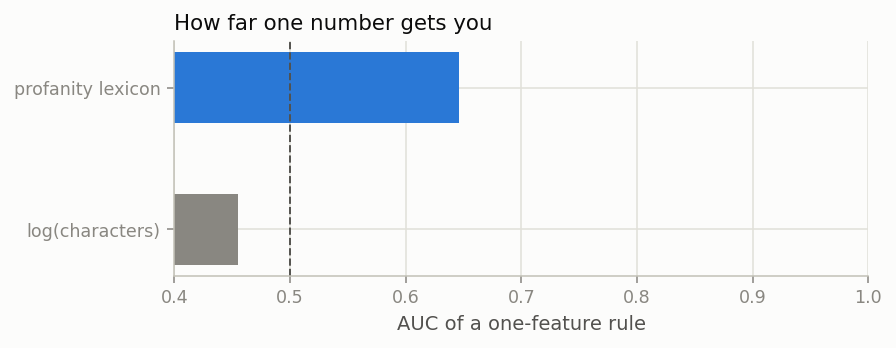

In [7]:
YES, NO = "#2a78d6", "#eb6834"
SURFACE, INK, INK_2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, GRID, AXIS = "#898781", "#e1e0d9", "#c3c2b7"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "grid.linestyle": "-", "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 9,
    "font.family": "sans-serif", "figure.dpi": 110,
})

rows = audit[audit.corpus == "Civil Comments"].set_index("feature")
features = ["log(characters)", "profanity lexicon"]

fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.barh(features, [rows.loc[f, "AUC"] for f in features], color=[MUTED, YES], height=0.5)
ax.axvline(0.5, color=INK_2, linewidth=1, linestyle="--")
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("AUC of a one-feature rule")
ax.set_title("How far one number gets you", loc="left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
MEDIA.mkdir(exist_ok=True)
fig.savefig(MEDIA / "confound_audit.png", dpi=140, bbox_inches="tight")
plt.close(fig)

Image(filename=str(MEDIA / "confound_audit.png"))

## 2. Asking a model to annotate

The model is **Qwen3-1.7B**, open weights, stored at **4-bit precision** so it fits in about 1.4 GB. It was run here on an RTX 2070 SUPER with 8 GB of GDDR6 VRAM.

**Zero-shot** means we describe the task and ask, with no examples and no training. This is the most simple starting point.

The rubric below is the definition the crowdworkers were given, including their four-point scale. 

This is done on the Civil Comments dataset. 

In [8]:
print(RUBRIC)

You are rating reader comments from a news website for toxicity.

The people who labelled these comments were asked: how toxic is this comment? They answered on a four-point scale.

  Very Toxic     a very hateful, aggressive or disrespectful comment, or one very likely to make someone leave the discussion.
  Toxic          a rude, disrespectful or unreasonable comment, or one somewhat likely to make someone leave the discussion.
  Hard to Say    you cannot tell.
  Not Toxic      none of the above.

Answer yes if the comment is Toxic or Very Toxic. Answer no otherwise.

Comment:
"""{comment}"""

Reply in exactly this format and nothing else:
LABEL: yes
REASON: <one short sentence>


In [9]:
zero_shot = annotate(evaluation.comment_id, RUBRIC)

records = cached_records(RUBRIC)
example = evaluation.iloc[0]
answer = records[str(example.comment_id)]
print(example.comment_text[:300])
print()
print(f"model says: {answer['label']}")
print(f"because:    {answer['reason']}")
print(f"humans:     {example.toxicity:.0%} of {example.n_raters} raters said toxic "
      f"-> {example.is_toxic}")

"Blame Obama, Bush, Clinton and Bush senior for not premptively dealing with this problem."

And what did you expect them to do?To drop a nuke or two on Pyongyang and then expect that nobody would react?

The wise minds of the world have come to the conclusion long time ago that a nuclear war is imp

model says: yes
because:    The comment is highly toxic and disrespectful, criticizing political figures and suggesting they should have acted differently, with a tone of aggression and frustration.
humans:     60% of 10 raters said toxic -> yes


## 3. Judging the labels

Accuracy is the share the model got right. If one comment in ten is toxic, a model that answers "no" to everything is 90% accurate and useless.

**Cohen's kappa** subtracts that free agreement:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

$p_o$ is the share of comments the model and the humans labelled identically. $p_e$ is the share they would have landed on together by chance, given how often each says yes. Kappa is the agreement the model earned over the agreement available to earn. Zero is guessing, one is perfect.

The third number below is not a score. **The share the model calls toxic** tells us what it usually does. This is something we can't infer directly from accuracy. 

In [10]:
def as_binary(labels):
    a = np.asarray(list(labels))
    if a.dtype.kind in "iub":
        return a.astype(int)
    return (np.char.lower(a.astype(str)) == "yes").astype(int)


def kappa(human, model):
    po = (human == model).mean(axis=-1)
    ph, pm = human.mean(axis=-1), model.mean(axis=-1)
    pe = ph * pm + (1 - ph) * (1 - pm)
    return np.where(pe < 1, (po - pe) / np.where(pe < 1, 1 - pe, 1), 0.0)


def scoreboard(human, models):
    h = as_binary(human)
    return pd.DataFrame({
        name: {"accuracy": (h == as_binary(m)).mean(),
               "agreement (kappa)": float(kappa(h, as_binary(m))),
               "calls it toxic": as_binary(m).mean()}
        for name, m in models.items()})


assert abs(float(kappa(as_binary(evaluation.is_toxic), as_binary(zero_shot)))
           - cohen_kappa_score(evaluation.is_toxic, zero_shot)) < 1e-12

truth = evaluation.is_toxic
scoreboard(truth, {"zero-shot": zero_shot}).round(3)

,zero-shot
accuracy,0.575
agreement (kappa),0.150
calls it toxic,0.765


One number from 200 comments is an estimate. The **bootstrap** says it's distribution: resample the 200 comments with replacement, ten thousand times, and take the middle 95% of the answers.

In [11]:
def fmt_ci(lo, hi):
    return f"[{lo:.2f}, {hi:.2f}]"


def bootstrap_kappa_ci(human, model, n_boot=10_000, alpha=0.05):
    h, m = as_binary(human), as_binary(model)
    draws = np.random.default_rng(SEED).integers(0, len(h), (n_boot, len(h)))
    lo, hi = np.percentile(kappa(h[draws], m[draws]),
                           [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {"kappa": float(kappa(h, m)), "lo": lo, "hi": hi, "n": len(h)}


zs_ci = bootstrap_kappa_ci(truth, zero_shot)

print(f"kappa {zs_ci['kappa']:.3f}, 95% CI {fmt_ci(zs_ci['lo'], zs_ci['hi'])}"
      f"  (from {zs_ci['n']} comments)")

kappa 0.150, 95% CI [0.04, 0.27]  (from 200 comments)


### What the humans managed

Every score here is agreement with a human label, so the target is not 1.0.

The corpus gives us the share of each panel who said toxic, and the panel size, so multiplying the two recovers how many people voted toxic. From the vote splits we can ask two questions.

**Did two raters agree with each other?** Draw two of a comment's raters and compare them.

**Did one rater agree with the majority of the others?** Leave one out, take the majority of the rest, compare.

The second is the model's test, because the model is graded against the majority label. A majority is an easier target than an individual, since averaging several people cancels some of their noise.

In [12]:
votes = read_set("rater_votes.csv")
detox_votes = read_set("detox_votes.csv")


def pairwise(n, k):
    # Chance that two raters drawn from one comment's panel said the same thing.
    return (k * (k - 1) + (n - k) * (n - k - 1)) / (n * (n - 1))


def one_vs_majority(n, k):
    # Chance that one rater matched the majority of the others. This is the one we care about more as the model is graded against that same majority. 
    return (k * ((k - 1) > (n - 1) / 2) + (n - k) * ~(k > (n - 1) / 2)) / n


def ceiling_row(frame, how):
    n = frame.n_raters.to_numpy(float)
    k = frame.n_toxic_votes.to_numpy(float)
    keep = n >= 3
    n, k = n[keep], k[keep]
    observed = how(n, k).mean()
    p = k.sum() / n.sum()
    majority = (k > n / 2).mean()
    chance = (p ** 2 + (1 - p) ** 2 if how is pairwise
              else p * majority + (1 - p) * (1 - majority))
    return {"comments": int(keep.sum()), "observed": observed, "chance": chance,
            "kappa": (observed - chance) / (1 - chance)}


eval_votes = votes[votes.comment_id.isin(set(evaluation.comment_id))]
detox_eval_votes = detox_votes[detox_votes.comment_id.isin(set(transfer.comment_id))]
panel = pd.cut(votes.n_raters, [2, 4, 10, 10**9],
               labels=["panels of 3 to 4", "panels of 5 to 10", "panels of 11 or more"])

rows = {
    ("two raters, each other", "the whole corpus"): ceiling_row(votes, pairwise),
    ("two raters, each other", "the evaluation set"): ceiling_row(eval_votes, pairwise),
    ("one rater, the majority", "the whole corpus"): ceiling_row(votes, one_vs_majority),
    ("one rater, the majority", "the evaluation set"): ceiling_row(eval_votes,
                                                                   one_vs_majority),
    ("one rater, the majority", "wikipedia detox"): ceiling_row(detox_eval_votes,
                                                                one_vs_majority),
}
for name, group in votes.groupby(panel, observed=True):
    rows[("two raters, each other", name)] = ceiling_row(group, pairwise)

ceiling = pd.DataFrame(rows).T
ceiling.index = pd.MultiIndex.from_tuples(ceiling.index, names=["comparison", "set"])
ceiling.round(3)

comments  observed  chance  \
comparison              set                                                
two raters, each other  the whole corpus      448000.0     0.837   0.519   
                        the evaluation set       200.0     0.704   0.511   
one rater, the majority the whole corpus      448000.0     0.876   0.581   
                        the evaluation set       200.0     0.695   0.474   
                        wikipedia detox          800.0     0.747   0.542   
two raters, each other  panels of 3 to 4      252602.0     1.000   0.994   
                        panels of 5 to 10     171993.0     0.629   0.573   
                        panels of 11 or more   23405.0     0.596   0.541   

                                              kappa  
comparison              set                          
two raters, each other  the whole corpus      0.660  
                        the evaluation set    0.395  
one rater, the majority the whole corpus      0.703  
                        the evaluation set    0.420  
                        wikipedia detox       0.447  
two raters, each other  panels of 3 to 4      0.981  
                        panels of 5 to 10     0.131  
                        panels of 11 or more  0.120

Two raters agree at kappa 0.660 across all 448,000 comments and at 0.395 on our 200. The evaluation set is balanced, half toxic and half not, and toxic comments are the ones that got flagged and sent to a bigger panel. The last three rows show it: comments seen by three or four raters agree at 0.981, because nearly all of those votes were a unanimous "not toxic". Comments seen by eleven or more agree at 0.120, as the toxic comments were the ones shown to more people so they cross the n = 3-4 barrier. 

**The number to hold a model against is 0.420**, one crowdworker against the majority of their colleagues on the evaluation set.

Our training sample was made half toxic and half-non toxic on purpose, and so was this evaluation set, so the model was told the base rate of the test and no rater was. Part of any margin over 0.420 is that head start.

In [13]:
said = lambda labels, who: pd.Series([f"{who}: {'toxic' if v == 'yes' else 'not toxic'}"
                                      for v in labels])

pd.crosstab(said(evaluation.is_toxic, "humans"),
            said(zero_shot, "model")).rename_axis(index=None, columns=None)

,model: not toxic,model: toxic
humans: not toxic,31,69
humans: toxic,16,84


## 4. Fine-tuning with QLoRA

Prompting rearranges what the model already does. Fine-tuning changes the model, by showing it labelled examples and adjusting weights when it gets them wrong.

Updating all 1.7 billion weights needs more memory than we have. **QLoRA** avoids it: the original weights stay frozen at 4 bits, small trainable matrices are attached to the frozen model, and only those are trained. 17.4 million of the model's 1.05 billion parameters are trainable, 1.66%, and what we save is a 78 MB adapter file.

About one comment in nine in this corpus is toxic, so a thousand comments drawn at that rate carry roughly a hundred toxic ones, too few for the model to learn that class. Our training sample is half toxic and half not. The model is being shown a world where toxicity is nine times more common than it is, and it will answer accordingly. Watch the "calls it toxic" column from here on.

In [14]:
train_log = json.loads((ARTIFACTS / "train_log_plain.json").read_text())

LORA = train_log["lora"]
print(f"rank {LORA['r']}, alpha {LORA['alpha']}, dropout {LORA['dropout']}")
print(f"trainable: {LORA['trainable_params']:,} parameters, "
      f"{LORA['trainable_pct']}% of the model")
print(f"precision: {train_log['precision']}")
print(f"batch {train_log['per_device_batch_size']} x {train_log['grad_accum']} accumulation "
      f"= {train_log['effective_batch']} comments per step")
print(f"{train_log['steps']} steps in {train_log['train_seconds'] / 60:.1f} minutes "
      f"({train_log['seconds_per_step']} s/step)")
print(f"peak GPU memory: {train_log['peak_vram_mib']:,} MiB of {train_log['vram_total_mib']:,}")
print(f"training data: {train_log['n_train']} comments, {train_log['share_toxic']:.0%} toxic")

rank 16, alpha 32, dropout 0.05
trainable: 17,432,576 parameters, 1.657% of the model
precision: fp16 (bf16 disabled, Turing sm_75 has no native bf16)
batch 2 x 8 accumulation = 16 comments per step
200 steps in 31.1 minutes (9.32 s/step)
peak GPU memory: 4,420 MiB of 8,191
training data: 1000 comments, 50% toxic


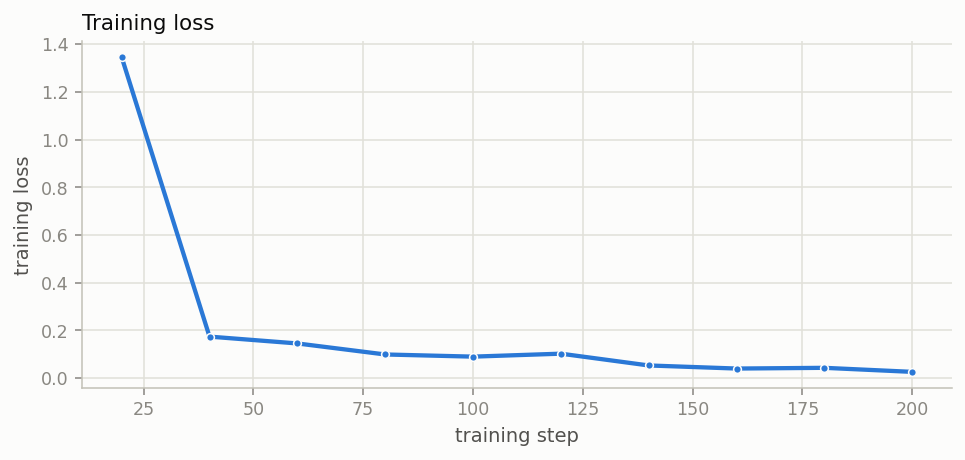

In [15]:
history = pd.DataFrame(train_log["history"])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(history.step, history.loss, color=YES, linewidth=2.2, marker="o", markersize=4,
        markeredgecolor=SURFACE, markeredgewidth=0.8)
ax.set_xlabel("training step")
ax.set_ylabel("training loss")
ax.set_title("Training loss", loc="left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(MEDIA / "training_loss.png", dpi=140, bbox_inches="tight")
plt.close(fig)

Image(filename=str(MEDIA / "training_loss.png"))

Loss against training step. It drops steeply over the first twenty steps, then declines slowly for the remaining one hundred and eighty. Most of that first drop is the model learning to answer in the two words the rubric asked for.

## 5. When did training stop helping?

A falling loss tells us the model fitted the training data. It does not tell us the labels got better. So during training we paused every 20 steps and pushed the same 200 probe comments through the model, recording two things.

What it answered, which gives a kappa coefficient. And the 2,048 numbers in its last hidden layer at the moment before it answered, which we fit a logistic regression to. The first is what the model says. The second is what the model knows.

In [16]:
checkpoints = dict(np.load(ARTIFACTS / "probe_checkpoints_plain.npz"))
steps, p_yes, probe_labels = (checkpoints["steps"], checkpoints["p_yes"],
                              checkpoints["labels"])

probe_accuracy = np.array([
    cross_val_score(LogisticRegression(max_iter=3000, C=0.01),
                    X.astype(np.float32), probe_labels, cv=5).mean()
    for X in checkpoints["hidden"]])

preds = (p_yes > 0.5).astype(int)
agreement = np.array([float(kappa(probe_labels, q)) for q in preds])

draws = np.random.default_rng(SEED).integers(0, len(probe_labels),
                                             (4000, len(probe_labels)))
band = np.array([np.percentile(kappa(probe_labels[draws], q[draws]), [2.5, 97.5])
                 for q in preds])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2),
                               gridspec_kw={"width_ratios": [1.35, 1]})
ax1.fill_between(steps, band[:, 0], band[:, 1], color=YES, alpha=0.16, linewidth=0)
ax1.plot(steps, agreement, color=YES, linewidth=2.4, marker="o", markersize=5,
         markeredgecolor=SURFACE, markeredgewidth=0.8)
ax1.set_xlabel("training step")
ax1.set_ylabel("agreement with humans (kappa)")
ax1.set_title("What it says", loc="left")

ax2.plot(steps, probe_accuracy, color=YES, linewidth=2.4, marker="o", markersize=5,
         markeredgecolor=SURFACE, markeredgewidth=0.8)
ax2.set_ylim(0.4, 1.0)
ax2.set_xlabel("training step")
ax2.set_ylabel("probe accuracy")
ax2.set_title("What it knows", loc="left")

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(MEDIA / "learning.png", dpi=140, bbox_inches="tight")
plt.close(fig)

pd.DataFrame({"step": steps, "agreement (kappa)": agreement.round(3),
              "probe accuracy": probe_accuracy.round(3)})

,step,agreement (kappa),probe accuracy
0,0,0.19,0.690
1,20,0.01,0.765
2,40,0.54,0.770
3,60,0.62,0.795
4,80,0.58,0.830
5,100,0.60,0.845
6,120,0.69,0.850
7,140,0.66,0.845
8,160,0.70,0.850
9,180,0.69,0.845


Look at step 20. Kappa is 0.01 and the model calls almost nothing toxic, so its answers are worthless. Probe accuracy at the same step is 0.765, up from 0.690 at step 0. The model had learned the answer format and swung to "no" on everything, while its internal state was already separating the two classes better than before training.

Kappa reaches 0.69 by step 120 and the last eighty steps add nothing.

## 6. Does it label better?

The same 200 comments, the same prompt, using the model we just fine-tuned.

zero-shot got 85 of 200 wrong; fine-tuned got 30 wrong
fine-tuning fixed 67 comments and broke 12


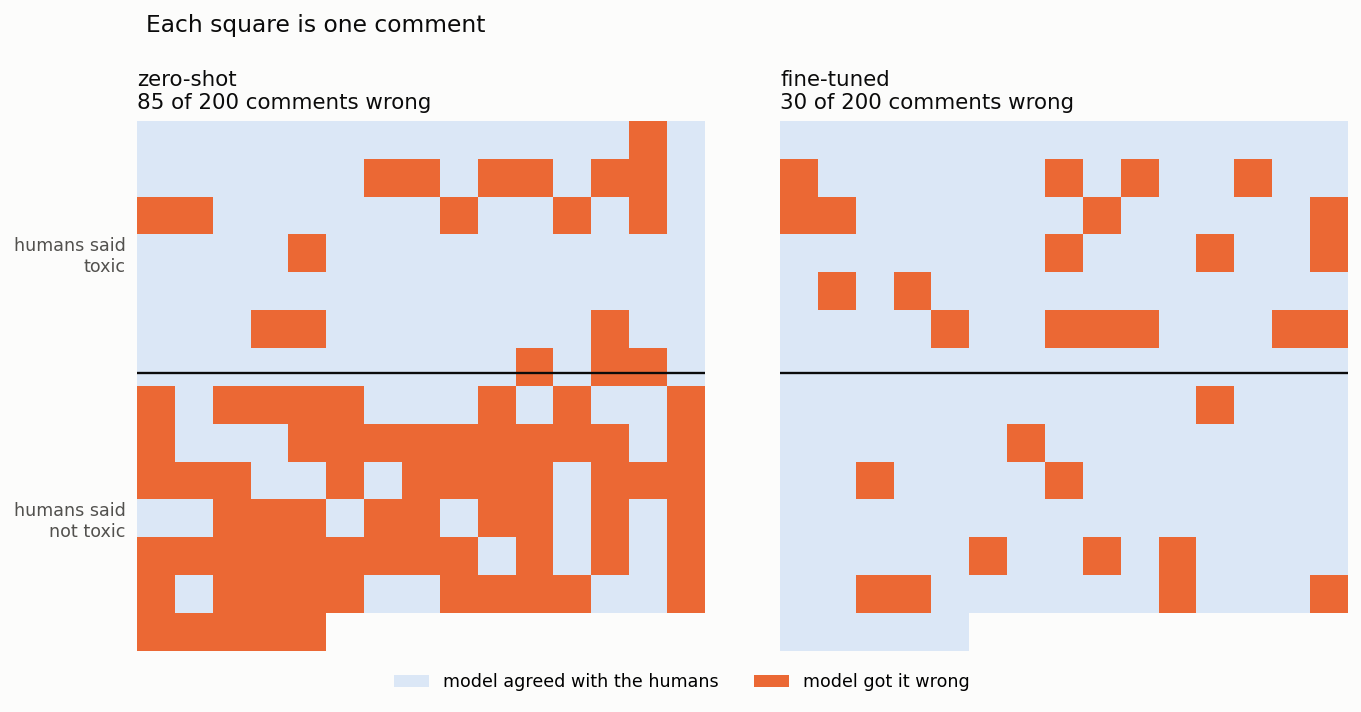

In [17]:
fine_tuned = annotate(evaluation.comment_id, RUBRIC, adapter=ADAPTER)

order = np.argsort(np.asarray(truth) != "yes", kind="stable")
in_order = np.asarray(truth)[order]
n = len(in_order)
cols = int(np.ceil(np.sqrt(n)))
rows_grid = int(np.ceil(n / cols))
split = (in_order == "yes").sum() / cols - 0.5
right = "#dbe7f6"

fig, axes = plt.subplots(1, 2, figsize=(10.2, 5.0))
counts_wrong = []
for ax, (name, pred) in zip(axes, (("zero-shot", zero_shot), ("fine-tuned", fine_tuned))):
    wrong = (np.asarray(pred)[order] != in_order).astype(int)
    counts_wrong.append(int(wrong.sum()))
    padded = np.full(rows_grid * cols, np.nan)
    padded[:n] = wrong
    ax.imshow(padded.reshape(rows_grid, cols), cmap=ListedColormap([right, NO]),
              vmin=0, vmax=1, interpolation="nearest")
    ax.axhline(split, color=INK, linewidth=1.2)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for side in ax.spines.values():
        side.set_visible(False)
    ax.set_title(f"{name}\n{wrong.sum()} of {n} comments wrong", loc="left")

axes[0].text(-0.8, split / 2, "humans said\ntoxic", ha="right", va="center",
             fontsize=9, color=INK_2)
axes[0].text(-0.8, (split + rows_grid) / 2, "humans said\nnot toxic", ha="right",
             va="center", fontsize=9, color=INK_2)
fig.legend(handles=[Patch(facecolor=right, label="model agreed with the humans"),
                    Patch(facecolor=NO, label="model got it wrong")],
           loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Each square is one comment", x=0.125, ha="left", fontsize=12, color=INK)
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(MEDIA / "before_after.png", dpi=140, bbox_inches="tight")
plt.close(fig)

wrong_before, wrong_after = counts_wrong
fixed = sum(z != t and f == t for t, z, f in zip(truth, zero_shot, fine_tuned))
broke = sum(z == t and f != t for t, z, f in zip(truth, zero_shot, fine_tuned))

print(f"zero-shot got {wrong_before} of {len(truth)} wrong; fine-tuned got {wrong_after} wrong")
print(f"fine-tuning fixed {fixed} comments and broke {broke}")
Image(filename=str(MEDIA / "before_after.png"))

Two grids of 200 squares, one square per comment, split by a horizontal line with the toxic comments above it. Pale squares are agreements, orange squares are errors. Left is before fine-tuning, right is after.

The error counts do not tell us whether they are the same errors, so the next table follows each comment across.

In [18]:
flows = pd.DataFrame({"truth": np.asarray(truth),
                      "zero_shot": np.asarray(zero_shot),
                      "fine_tuned": np.asarray(fine_tuned),
                      "text": np.asarray(evaluation.comment_text),
                      "toxicity": np.asarray(evaluation.toxicity),
                      "n_raters": np.asarray(evaluation.n_raters)})
flows["zs_ok"] = np.where(flows.zero_shot == flows.truth, "right", "wrong")
flows["ft_ok"] = np.where(flows.fine_tuned == flows.truth, "right", "wrong")

pd.crosstab(pd.Series([f"zero-shot: {v}" for v in flows.zs_ok]),
            pd.Series([f"fine-tuned: {v}" for v in flows.ft_ok])
            ).rename_axis(index=None, columns=None)

,fine-tuned: right,fine-tuned: wrong
zero-shot: right,103,12
zero-shot: wrong,67,18


In [19]:
def show_flow(frame, before, after, limit=4):
    rows = frame[(frame.zs_ok == before) & (frame.ft_ok == after)]
    label = lambda v: "toxic" if v == "yes" else "not toxic"
    for row in rows.head(limit).itertuples():
        print(f"humans: {label(row.truth)}    zero-shot: {label(row.zero_shot)}    "
              f"fine-tuned: {label(row.fine_tuned)}    "
              f"({row.toxicity:.0%} of {row.n_raters} raters said toxic)")
        print(" ".join(str(row.text).split()))
        print()


mild_flows = flows if SHOW_STRONG else flows[flows.toxicity < 0.7]

print(f"comments fine-tuning broke ({broke} in total, showing the milder ones):\n")
show_flow(mild_flows, "right", "wrong")

comments fine-tuning broke (12 in total, showing the milder ones):

humans: toxic    zero-shot: toxic    fine-tuned: not toxic    (60% of 10 raters said toxic)
But it violates his religious beliefs because they are homosexual. So the distinction you attempt to make collapses (for me). People who hold certain conservative political beliefs violate my religious beliefs (seriously). If I owned a coffee shop, and someone who planned to attend a pro-conservative political event came in to order ten coffees to take to that event for his or her fellow attendees, would I have a right to refuse to serve them?

humans: toxic    zero-shot: toxic    fine-tuned: not toxic    (60% of 10 raters said toxic)
Then after the woman that Newtie was cheating with tried him out as a husband and is now divorcing him. Even Newties money can't keep a warm body in his bed.

humans: toxic    zero-shot: toxic    fine-tuned: not toxic    (50% of 10 raters said toxic)
I am very, very happy with the entire transition

Printing the comments that got worse shows which direction the losses run. All twelve were toxic comments the fine-tuned model let through, so it traded false alarms for misses.

In [20]:
def bootstrap_kappa_diff_ci(human, a, b, n_boot=10_000, alpha=0.05):
    h, a, b = as_binary(human), as_binary(a), as_binary(b)
    draws = np.random.default_rng(SEED).integers(0, len(h), (n_boot, len(h)))
    hd = h[draws]
    lo, hi = np.percentile(kappa(hd, b[draws]) - kappa(hd, a[draws]),
                           [100 * alpha / 2, 100 * (1 - alpha / 2)])
    ka, kb = float(kappa(h, a)), float(kappa(h, b))
    return {"a": ka, "b": kb, "diff": kb - ka, "lo": lo, "hi": hi, "n": len(h)}


ft_ci = bootstrap_kappa_ci(truth, fine_tuned)
gain = bootstrap_kappa_diff_ci(truth, zero_shot, fine_tuned)
human_ceiling = ceiling.loc[("one rater, the majority", "the evaluation set"), "kappa"]

print(f"zero-shot     kappa {zs_ci['kappa']:.3f}  {fmt_ci(zs_ci['lo'], zs_ci['hi'])}")
print(f"fine-tuned    kappa {ft_ci['kappa']:.3f}  {fmt_ci(ft_ci['lo'], ft_ci['hi'])}")
print(f"gain               {gain['diff']:+.3f}  {fmt_ci(gain['lo'], gain['hi'])}"
      "   (paired on each resample of the same comments)")
print(f"one rater     kappa {human_ceiling:.3f}: this is our target")
print()
scoreboard(truth, {"zero-shot": zero_shot, "fine-tuned": fine_tuned}).round(3)

zero-shot     kappa 0.150  [0.04, 0.27]
fine-tuned    kappa 0.700  [0.60, 0.80]
gain               +0.550  [0.41, 0.68]   (paired on each resample of the same comments)
one rater     kappa 0.420: this is our target



,zero-shot,fine-tuned
accuracy,0.575,0.85
agreement (kappa),0.150,0.70
calls it toxic,0.765,0.46


The zero-shot model called 76.5% of comments toxic when half of them were. Fine-tuning moved that to 46% and took kappa past the rater target. Section 1A said a swear-word counter reaches AUC 0.646 here, so part of this is the model learning which words are rude.

## 7. Does it work on different data?

Everything so far is one corpus. A model trained on Civil Comments has only ever seen news comments moderated by one plugin.

We move to **Wikipedia Detox**: comments from Wikipedia talk pages, rated for toxicity by crowdworkers. It was built by the same group at Jigsaw that made Civil Comments, and the question is the same one. Raters were asked how toxic a comment is, and the label is built the same way, the share of raters on the toxic side at half.

Holding the question fixed is what makes the results comparable. 

The corpus changes a lot. These are arguments between people editing an encyclopedia, from 2001 to 2016 where Civil Comments runs 2015 to 2017. Two differences we cannot remove: Detox gave raters five options where Civil Comments gave four, and its comments were reconstructed from revision histories, so newlines and quotes arrived as placeholder tokens. We convert those back before the model sees anything.

Both evaluation sets are balanced half and half, so kappa is not moving on base rates. One rater against the majority reaches 0.420 on Civil Comments and 0.447 here, so the two corpora are about equally hard for people to agree.


In [21]:
MODELS = {"zero-shot": None, "fine-tuned": ADAPTER}
transfer_truth = transfer.is_toxic

rows = {}
for name, adapter in MODELS.items():
    home = as_binary(annotate(evaluation.comment_id, RUBRIC, adapter=adapter))
    away = as_binary(annotate(transfer.comment_id, RUBRIC, adapter=adapter))
    rows[name] = {
        "kappa, Civil Comments": float(kappa(as_binary(truth), home)),
        "kappa, Wikipedia": float(kappa(as_binary(transfer_truth), away)),
        "calls it toxic, Wikipedia": away.mean(),
    }

gain = bootstrap_kappa_diff_ci(transfer_truth,
                               annotate(transfer.comment_id, RUBRIC),
                               annotate(transfer.comment_id, RUBRIC, adapter=ADAPTER))
print(f"fine-tuning gains {gain['diff']:+.3f} kappa on Wikipedia "
      f"{fmt_ci(gain['lo'], gain['hi'])}, measured on {len(transfer)} comments.")
print("Half of those comments are toxic, so the last column should sit near 0.5.")
print()

pd.DataFrame(rows).T.round(3)

fine-tuning gains +0.228 kappa on Wikipedia [0.16, 0.30], measured on 800 comments.


Half of those comments are toxic, so the last column should sit near 0.5.



,"kappa, Civil Comments","kappa, Wikipedia","calls it toxic, Wikipedia"
zero-shot,0.15,0.515,0.555
fine-tuned,0.70,0.742,0.394


The model scores higher on the corpus it has never seen than on the one it was trained on.

Read the zero-shot row first. With no fine-tuning, our original model reaches 0.515 on Wikipedia against 0.150 on Civil Comments. It already finds Wikipedia easier, so the gap is a fact about the two corpora not the training.

So the transfer result is the gain: fine-tuning on news comments moved kappa from 0.515 to 0.742 on encyclopedia arguments the model was never shown, and the interval does not contain zero. The absolute score travelled too, mostly by landing the data being simpler.

The last column is the check we set up in section 4. Half of these 800 comments are toxic. The zero-shot model calls 55.5% of them toxic and the fine-tuned model 39.4%, so training on a half-and-half sample moved the model toward the right rate on a corpus it had never seen.

## Conclusion

Fine-tuning moved agreement with the human labels from kappa 0.150 to 0.700, and carried +0.228 of that onto a corpus of Wikipedia arguments the model had never seen. A swear-word counter reaches AUC 0.646 on this task, so part of what the model learned is which words are rude. And one crowdworker set against the majority of their colleagues reaches kappa 0.420 here, so the target was never 1.0. EXPAND HERE

### Data and licences

**Civil Comments.** About 1.8 million comments from fifty English-language news sites, 2015 to 2017, released by Jigsaw when the platform closed. CC0-1.0 covering the comment text, so the sampled comments ship here. We use a 448,000-comment subset, from the `pietrolesci/civilcomments-wilds` mirror, because the plain HuggingFace build drops the article field the split needs. Jigsaw drew that subset partly for comments mentioning identity terms, so its toxic rate runs higher than the corpus as a whole.

**Wikipedia Detox, Toxicity.** 159,686 comments from English Wikipedia talk pages, 2001 to 2016, each rated by around ten crowdworkers. Released by Jigsaw and the Wikimedia Foundation under CC0, from figshare item 4563973. We use the `random` portion only; the release also contains an oversample drawn from around user-block events.

**Qwen3-1.7B.** Apache 2.0, quantised by Unsloth as `unsloth/Qwen3-1.7B-unsloth-bnb-4bit`.

Model weights and the trained adapters are not in this repository. Every model answer here was saved to `cache/` when the scripts in `model_call_scripts/` were run on a GPU.

### References

Borkan, D., Dixon, L., Sorensen, J., Thain, N. & Vasserman, L. (2019). Nuanced metrics for measuring unintended bias with real data for text classification. *WWW '19 Companion*. https://arxiv.org/abs/1903.04561

Wulczyn, E., Thain, N. & Dixon, L. (2017). Ex Machina: Personal attacks seen at scale. *WWW 2017*. https://arxiv.org/abs/1610.08914

Goyal, N., Kivlichan, I. D., Rosen, R. & Vasserman, L. (2022). Is your toxicity my toxicity? Exploring the impact of rater identity on toxicity annotation. *Proceedings of the ACM on Human-Computer Interaction* 6(CSCW2). https://arxiv.org/abs/2205.00501

Dettmers, T., Pagnoni, A., Holtzman, A. & Zettlemoyer, L. (2023). QLoRA: Efficient finetuning of quantized LLMs. *NeurIPS 2023*. https://arxiv.org/abs/2305.14314

Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L. & Chen, W. (2022). LoRA: Low-rank adaptation of large language models. *ICLR 2022*. https://arxiv.org/abs/2106.09685